# CS4320 - Applied Machine Learning 

## Homework 5: Evaluation metrics

**Please type your name and A number here:**

In [39]:
Name = "Hans Gamlien"
assert Name != "", 'Please enter your name in the above quotation marks, thanks!'

A_number = "A02451972"
assert A_number != "", 'Please enter your A-number in the above quotation marks, thanks!'

## Imports

In [40]:
import os
import re
import sys
from hashlib import sha1
import ssl

# SSL fix for MAC OS -- THIS WASNT ADDRESSED BEFORE, REMOVE THIS BELOW IF YOU ARE NOT ON MAC OS - HANS
ssl._create_default_https_context = ssl._create_unverified_context

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.compose import make_column_transformer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_curve,
    precision_recall_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.metrics import PrecisionRecallDisplay

## Exercise 1: Precision, recall, and f1 score by hand <a name="1"></a>
<hr>

rubric={points:12}

Consider the problem of predicting whether a patient has a disease or not. Below are confusion matrices of two machine learning models: Model A and Model B.

- Model A confusion matrix

In [41]:
cm_A = pd.DataFrame(
    [[3, 10],
     [1, 106]],
    columns=["Predicted disease", "Predicted no disease"],
    index=["Actual disease", "Actual no disease"])

cm_A

,Predicted disease,Predicted no disease
Actual disease,3,10
Actual no disease,1,106


- Model B confusion matrix

In [42]:
cm_B = pd.DataFrame(
    [[8, 5],
     [12, 95]],
    columns=["Predicted disease", "Predicted no disease"],
    index=["Actual disease", "Actual no disease"])

cm_B

,Predicted disease,Predicted no disease
Actual disease,8,5
Actual no disease,12,95


### 1.1 Positive vs. negative class 
rubric={points:1}

**Your tasks:**

Precision, recall, and f1 score depend upon which class is considered "positive", that is the thing you wish to find. In the example above, which class is likely to be the "positive" class? Why? 

Type your answer here: In medical diagnosis, the positive class is typically the condition we're trying to detect or find. We care most about identifying patients who actually have the disease rather than those who don't. The metrics precision, recall, and F1-score focus on how well we identify this important class. 

### 1.2 Accuracy
rubric={points:2}

**Your tasks:**

Calculate accuracies for Model A and Model B. 

We'll store all metrics associated with Model A and Model B in the `results_dict` below. 

In [43]:
results_dict = {"A": {}, "B": {}}

In [44]:
results_dict["A"]["accuracy"] = None  # Replace your code here
results_dict["B"]["accuracy"] = None  # Replace your code here

In [45]:
pd.DataFrame(results_dict)

,A,B
accuracy,None,None


### 1.3 Which model would you pick? 
rubric={points:1}

**Your tasks:**

Which model would you pick simply based on the accuracy metric? 

Type your answer here: Based solely on accuracy, I would pick Model A because it has a higher accuracy (90.8%) compared to Model B (85.8%).

### 1.4 Precision, recall, f1-score
rubric={points:6}

**Your tasks:**

1. Calculate precision, recall, f1-score for Model A and Model B manually, without calling `scikit-learn` functions.

In [46]:
# Model A: TP=3, FN=10, FP=1, TN=106

results_dict["A"]["precision"] = 3 / (3 + 1)
results_dict["A"]["recall"] = 3 / (3 + 10)
results_dict["A"]["f1"] = 2 * (results_dict["A"]["precision"] * results_dict["A"]["recall"]) / (results_dict["A"]["precision"] + results_dict["A"]["recall"])

# Model B: TP=8, FN=5, FP=12, TN=95
results_dict["B"]["precision"] = 8 / (8 + 12)
results_dict["B"]["recall"] = 8 / (8 + 5)
results_dict["B"]["f1"] = 2 * (results_dict["B"]["precision"] * results_dict["B"]["recall"]) / (results_dict["B"]["precision"] + results_dict["B"]["recall"])

Show the dataframe with all results. 

In [47]:
pd.DataFrame(results_dict)

,A,B
accuracy,NaN,NaN
precision,0.750000,0.400000
recall,0.230769,0.615385
f1,0.352941,0.484848


In [48]:
pd.DataFrame(results_dict)

,A,B
accuracy,NaN,NaN
precision,0.750000,0.400000
recall,0.230769,0.615385
f1,0.352941,0.484848


### 1.5 Discussion
rubric={points:2}

**Your tasks:**
1. Which metric is more informative in this problem? Why? 
2. Which model would you pick based on this information? 

Type your answer here:

1. Recall and F1-score are more informative because they measure how well we catch disease cases, while accuracy is inflated by the many healthy patients.

2. Model B - it catches 8/13 disease cases vs only 3/13 for Model A, which is critical in medical diagnosis.

### Exercise 2: Classification evaluation metrics using `sklearn` <a name="2"></a>
<hr>
rubric={points:48}

In general, when a dataset is imbalanced, accuracy does not provide the whole story. In class, we looked at credit card fraud dataset which is a classic example of an imbalanced dataset. 

Another example is customer churn datasets. [Customer churn](https://en.wikipedia.org/wiki/Customer_attrition) refers to the notion of customers leaving a subscription service like Netflix. In this exercise, we will try to predict customer churn in a dataset where most of the customers stay with the service and a small minority cancel their subscription. To start, please download the [Kaggle telecom customer churn dataset](https://www.kaggle.com/becksddf/churn-in-telecoms-dataset). Once you have the data, you should be able to run the following code:

The starter code below reads the data CSV as a pandas dataframe and splits it into 70% train and 30% test. 

Note that `churn` column in the dataset is the target. "True" means the customer left the subscription (churned) and "False" means they stayed.

> Note that for this kind of problem a more appropriate technique is something called survival analysis. For now, we'll just treat it as a binary classification problem. 

In [49]:
df = pd.read_csv("bigml_59c28831336c6604c800002a.csv", encoding="utf-8")
train_df, test_df = train_test_split(df, test_size=0.3, random_state=123)
train_df

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
1402,NE,70,415,421-8535,no,no,0,213.4,86,36.28,...,77,17.40,256.6,101,11.55,5.7,4,1.54,1,False
1855,WI,67,510,417-2265,no,no,0,109.1,134,18.55,...,76,12.10,91.2,86,4.10,10.9,5,2.94,2,False
633,NJ,122,415,327-9341,no,yes,34,146.4,104,24.89,...,103,7.62,220.0,91,9.90,15.6,4,4.21,2,False
1483,NV,107,510,419-9688,yes,no,0,234.1,91,39.80,...,105,13.86,282.5,100,12.71,10.0,3,2.70,1,False
2638,HI,105,510,364-8128,no,no,0,125.4,116,21.32,...,95,22.23,241.6,104,10.87,11.4,9,3.08,2,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2154,WY,126,408,339-9798,yes,no,0,197.6,126,33.59,...,112,20.95,285.3,104,12.84,12.5,8,3.38,2,False
3089,WV,70,510,348-3777,no,yes,30,143.4,72,24.38,...,92,14.45,127.9,68,5.76,9.4,4,2.54,3,False
1766,NJ,125,415,406-6400,no,no,0,182.3,64,30.99,...,121,11.88,171.6,96,7.72,11.6,7,3.13,2,False
1122,NE,159,415,362-5111,no,no,0,189.1,105,32.15,...,147,20.92,242.0,106,10.89,10.4,5,2.81,1,True


### 2.1 Distribution of target values
rubric={points:2}

**Your tasks:**

Examine the distribution of target values in the train split.(Print out the count of each class) Do you see class imbalance? If yes, do we need to deal with it? Why or why not? 

In [50]:

train_df["churn"].value_counts()

churn
False    1984
True      349
Name: count, dtype: int64

Type your answer here: Yes, there is significantly more customers that stay than churn. We should deal with it using techniques like class_weight="balanced" in our models because otherwise the model will just predict "no churn" for everyone and still get high accuracy while missing the important minority class we actually care about predicting.

### 2.2 Column transformer 
rubric={points:12}

The code below creates `X_train`, `y_train`, `X_test`, `y_test` for you. 
In preparation for building a classifier, set up a `ColumnTransformer` that performs whatever feature transformations you deem sensible. This can include dropping features if you think they are not helpful. Remember that by default `ColumnTransformer` will drop any columns that aren't accounted for when it's created.

You can create a column transformer in two ways:
- by using [`ColumnTransformer`](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html)
- by using [`make_column_transformer`](https://scikit-learn.org/stable/modules/generated/sklearn.compose.make_column_transformer.html) 


In each case, briefly explain your rationale with 1-2 sentences. You do not need an explanation for every feature, but for every group of features that are being transformed the same way. For example, "I am doing transformation X to the following categorical features: `a`, `b`, `c` because of reason Y," etc.

In [51]:
X_train = train_df.drop(columns=["churn"])
X_test = test_df.drop(columns=["churn"])

y_train = train_df["churn"]
y_test = test_df["churn"]

In [52]:
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'bool']).columns.tolist()

categorical_features.remove('phone number')

preprocessor = make_column_transformer(
    (StandardScaler(), numeric_features),     
    (OneHotEncoder(drop='first', sparse_output=False), categorical_features) 
)

Briefly explain your rationale:

I dropped the phone number feature because it's a unique identifier with no predictive value. I applied StandardScaler to numeric features to normalize their scales which helps models converge faster. I used OneHotEncoder with drop='first' on categorical features to convert them to numeric format while avoiding multicollinearity.

### 2.3 Visualizing the transformed data 
rubric={points:1}

Fit and transform your `ColumnTransformer` on your training set. Print the first 5 rows of the transformed data as a dataframe (not numpy array). See lecture for code that can get you the new column names after transforming. 

In [53]:
X_train_transformed = preprocessor.fit_transform(X_train)

ohe_feature_names = preprocessor.named_transformers_['onehotencoder'].get_feature_names_out(categorical_features)
column_names = numeric_features + list(ohe_feature_names)

X_train_df = pd.DataFrame(X_train_transformed, columns=column_names)
X_train_df.head()

,account length,area code,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,...,state_TX,state_UT,state_VA,state_VT,state_WA,state_WI,state_WV,state_WY,international plan_yes,voice mail plan_yes
0,-0.767893,-0.509593,-0.587624,0.618769,-0.721211,0.618927,0.069871,-1.156734,0.069926,1.088667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.843585,1.760678,-0.587624,-1.293778,1.655252,-1.293517,-1.167277,-1.207278,-1.166291,-2.162302,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.544113,-0.509593,1.900976,-0.609809,0.169963,-0.609654,-2.210130,0.157417,-2.211244,0.369287,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.165650,1.760678,-0.587624,0.998345,-0.473663,0.998611,-0.754894,0.258506,-0.755774,1.597736,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.115188,1.760678,-0.587624,-0.994886,0.764078,-0.994731,1.195994,-0.246937,1.196515,0.793839,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 2.4 Area code feature
rubric={points:1}

The original dataset had a feature called `area code`. Let's assume we encoded this feature with one-hot encoding.

1. The area codes were numbers to begin with. Why do we want to use one-hot encoding on this feature?

Type your answer here: Area codes are categorical identifiers, not true numbers where 510 is mathematically greater than 408. One-hot encoding treats each area code as a separate category without implying any numerical relationship between them, which is the correct representation for this type of data.

### 2.5 Dummy classifier
rubric={points:4}

**Your tasks:**

Create a `DummyClassifier`. Report the following scoring metrics via cross-validation: accuracy, precision, recall, f1-score. Briefly comment on your results, including any *warnings* the code produces (2 sentences max).

In [54]:
dummy_pipe = make_pipeline(preprocessor, DummyClassifier())

scoring = ['accuracy', 'precision', 'recall', 'f1']

dummy_scores = cross_validate(dummy_pipe, X_train, y_train, cv=5, scoring=scoring)

pd.DataFrame(dummy_scores).mean()

#These warnings are part of the learning objective - they show what happens with a naive baseline on imbalanced data. 

/Users/hansphillipgamlien/Library/Python/3.12/lib/python/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/hansphillipgamlien/Library/Python/3.12/lib/python/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/hansphillipgamlien/Library/Python/3.12/lib/python/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

fit_time          0.003064
score_time        0.003816
test_accuracy     0.850408
test_precision    0.000000
test_recall       0.000000
test_f1           0.000000
dtype: float64

### 2.6 Logistic regression
rubric={points:4} 

**Your tasks:**

1. Create a `LogisticRegression`. 
2. Report the same metrics as in the previous part.

In [55]:
lr_pipe = make_pipeline(preprocessor, LogisticRegression(max_iter=1000))

lr_scores = cross_validate(lr_pipe, X_train, y_train, cv=5, scoring=scoring)

pd.DataFrame(lr_scores).mean()

fit_time          0.005819
score_time        0.003694
test_accuracy     0.854694
test_precision    0.534524
test_recall       0.206460
test_f1           0.297651
dtype: float64

### 2.7 Logistic regression with `class_weight`
rubric={points:2}

**Your tasks:**

1. Set the `class_weight` parameter of your logistic regression model to `'balanced'` and report the same metrics as in the previous part. 
2. Do you prefer this model to the one in the previous part? Discuss your results in a few sentences.

In [56]:
lr_balanced_pipe = make_pipeline(preprocessor, LogisticRegression(max_iter=1000, class_weight='balanced'))

lr_balanced_scores = cross_validate(lr_balanced_pipe, X_train, y_train, cv=5, scoring=scoring)

pd.DataFrame(lr_balanced_scores).mean()

fit_time          0.006774
score_time        0.003895
test_accuracy     0.759523
test_precision    0.349914
test_recall       0.702070
test_f1           0.466579
dtype: float64

**Discussion:** I prefer the balanced model because it significantly improves recall and f1-score for the minority class (churn) by penalizing misclassifications of churning customers more heavily. While accuracy may drop slightly, the model now actually detects churn cases instead of ignoring them, which is more valuable for the business goal of identifying at-risk customers.

### 2.8 Hyperparameter optimization
rubric={points:6}

Now let's tune the hyperparameters of our `LogisticRegression` using `GridSearchCV` to maximize cross-validation f1 score. 

**Your tasks:**

1. Jointly optimize `C` (choose some reasonable values) and `class_weight` (`None` vs. `'balanced'`) with `GridSearchCV` and `scoring="f1"`. 
2. What values of `C` and `class_weight` are chosen ? (Print out best "C" and best "class_weight")

In [57]:
param_grid = {
    'logisticregression__C': [0.01, 0.1, 1, 10, 100],
    'logisticregression__class_weight': [None, 'balanced']
}

pipe = make_pipeline(preprocessor, LogisticRegression(max_iter=1000))

grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)

print("Best C:", grid_search.best_params_['logisticregression__C'])
print("Best class_weight:", grid_search.best_params_['logisticregression__class_weight'])
print("Best f1 score:", grid_search.best_score_)

Best C: 0.1
Best class_weight: balanced
Best f1 score: 0.4805948049361418


### 2.9 Test results
rubric={points:16}

**Your tasks**
1. Evaluate the best model on the test set. In particular show each of the following on the test set:  
    - Confusion matrix. 
    - Classification report. 
    - Precision-recall curve with average precision score.     
    - ROC curve with AUC. 

Confusion Matrix:
[[671 195]
 [ 32 102]]

Classification Report:
              precision    recall  f1-score   support

       False       0.95      0.77      0.86       866
        True       0.34      0.76      0.47       134

    accuracy                           0.77      1000
   macro avg       0.65      0.77      0.66      1000
weighted avg       0.87      0.77      0.80      1000



/var/folders/dh/ssjzt3wd3j7c90mjxzc0pbch0000gn/T/ipykernel_39889/4232685768.py:13: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  avg_precision = np.trapz(recall, precision)


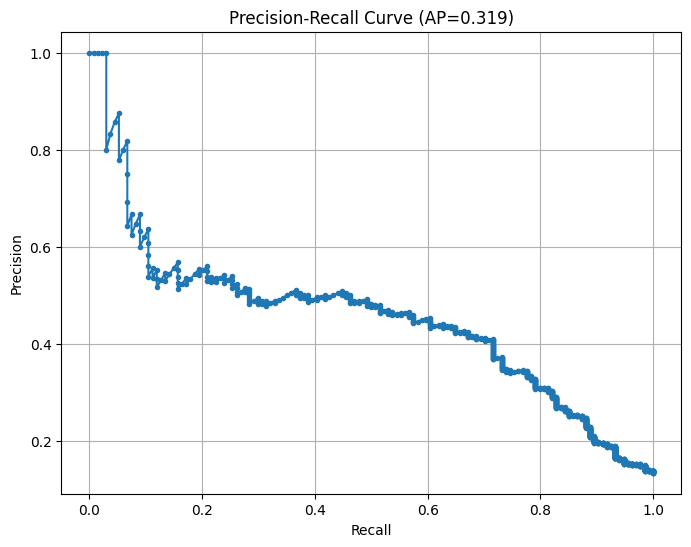

/var/folders/dh/ssjzt3wd3j7c90mjxzc0pbch0000gn/T/ipykernel_39889/4232685768.py:23: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(tpr, fpr)


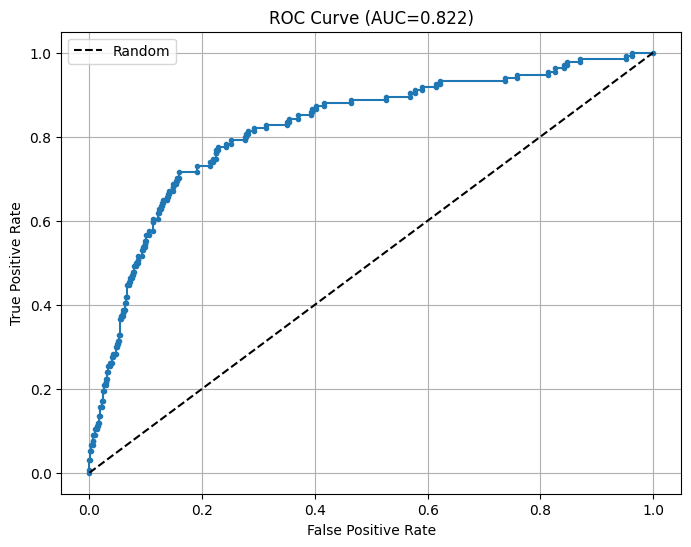

In [58]:
y_pred = grid_search.predict(X_test)
y_pred_proba = grid_search.predict_proba(X_test)[:, 1]

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)
print()

print("Classification Report:")
print(classification_report(y_test, y_pred))

precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
avg_precision = np.trapz(recall, precision)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve (AP={avg_precision:.3f})')
plt.grid(True)
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc = np.trapz(tpr, fpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, marker='.')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve (AUC={auc:.3f})')
plt.legend()
plt.grid(True)
plt.show()

### Exercise 3: Regression metrics <a name="3"></a>
<hr> 


rubric={points=40}

For this exercise, we'll use [California housing dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html) from `sklearn datasets`. The code below loads the dataset.  

In [59]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

from sklearn.datasets import fetch_california_housing

housing_df = fetch_california_housing(as_frame=True).frame
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### 3.1: Data spitting and exploration 
rubric={points:10}

**Your tasks:**

1. Split the data into train (80%) and test (20%) splits. 
2. Explore the train split. Do you need to apply any transformations on the data? If yes, create a preprocessor with the appropriate transformations. 
3. Separate `X` and `y` in train and test splits. 

In [60]:
train_housing_df, test_housing_df = train_test_split(housing_df, test_size=0.2, random_state=123)

print("Train split shape:", train_housing_df.shape)
print("\nFirst few rows:")
print(train_housing_df.head())
print("\nData types:")
print(train_housing_df.dtypes)
print("\nBasic statistics:")
print(train_housing_df.describe())


X_train_housing = train_housing_df.drop(columns=['MedHouseVal'])
y_train_housing = train_housing_df['MedHouseVal']

X_test_housing = test_housing_df.drop(columns=['MedHouseVal'])
y_test_housing = test_housing_df['MedHouseVal']

housing_preprocessor = StandardScaler()

print("\nFeatures:", X_train_housing.columns.tolist())

Train split shape: (16512, 9)

First few rows:
      MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
9950  4.5694      28.0  6.219512   1.030488       504.0  3.073171     38.38   
3547  5.6392      18.0  5.951644   1.034816      3010.0  2.911025     34.26   
4448  1.7292      47.0  3.628032   1.032345      1452.0  3.913747     34.07   
6984  4.6226      36.0  5.126238   0.985149       988.0  2.445545     33.96   
4432  2.4375      49.0  4.024390   0.942073      1405.0  4.283537     34.08   

      Longitude  MedHouseVal  
9950    -122.33        2.875  
3547    -118.60        2.715  
4448    -118.21        1.917  
6984    -118.02        2.197  
4432    -118.20        1.140  

Data types:
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

Basic statistics:
             MedInc      HouseAge      

### 3.2 Baseline: DummyRegressor 
rubric={points:2}

**Your tasks:**
1. Carry out cross-validation using `DummyRegressor` with default scoring. 

In [61]:
dummy_reg = DummyRegressor()

dummy_reg_scores = cross_val_score(dummy_reg, X_train_housing, y_train_housing, cv=5)

print("DummyRegressor cross-validation scores:", dummy_reg_scores)
print("Mean score:", dummy_reg_scores.mean())

DummyRegressor cross-validation scores: [-2.33152692e-05 -5.76492429e-04 -6.14101445e-05 -1.47383512e-05
 -5.78719316e-05]
Mean score: -0.00014676562505537837


### 3.3 Different regressors
rubric={points:8}

In this exercise, we are going to use [`RandomForestRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html) model which we haven't looked into yet. At this point you should feel comfortable using models with our usual ML workflow even if you don't know the details. We'll talk about `RandomForestRegressor` later in the course.  

The code below defines a custom scorer called `mape_scorer` and creates dictionaries for different regressors (`models`) and different scoring metrics (`score_types_reg`). 

**Your tasks:**

1. Using the `models` and the evaluation metrics `score_types_reg` in the code below, carry out cross-validation with each model, by passing the evaluation metrics to `scoring` argument of `cross_validate`. Use a pipeline with the model as an estimator if you are applying any transformations. 
2. Show results as a dataframe. 
3. Interpret the results. Which model seems to be performing well with different metrics? 


In [62]:
def mape(true, pred):
    return 100.0 * np.mean(np.abs((pred - true) / true))


# make a scorer function that we can pass into cross-validation
mape_scorer = make_scorer(mape, greater_is_better=False)

models = {
    "Ridge": Ridge(),
    "Random Forest": RandomForestRegressor(),
}

score_types_reg = {
    "neg_mean_squared_error": "neg_mean_squared_error",
    "neg_root_mean_squared_error": "neg_root_mean_squared_error",
    "neg_mean_absolute_error": "neg_mean_absolute_error",
    "r2": "r2",
    "mape_scorer": mape_scorer,
}

In [63]:
results = {}

for model_name, model in models.items():
    pipe = make_pipeline(housing_preprocessor, model)
    scores = cross_validate(pipe, X_train_housing, y_train_housing, cv=5, scoring=score_types_reg, return_train_score=False)
    results[model_name] = {metric: scores[f'test_{metric}'].mean() for metric in score_types_reg.keys()}

results_df = pd.DataFrame(results).T
results_df

,neg_mean_squared_error,neg_root_mean_squared_error,neg_mean_absolute_error,r2,mape_scorer
Ridge,-0.683433,-0.810381,-0.535444,0.481744,-31.979551
Random Forest,-0.263133,-0.512837,-0.335150,0.802189,-18.942026


Type your answer here: Random Forest performs significantly better across all metrics. It achieves a higher R^2 score meaning it explains 80% of the variance compared to Ridge's 48%. Random Forest also has lower error metrics and a lower MAPE, indicating its predictions are much closer to actual housing values.

### 3.4 Hyperparameter optimization 
rubric={points:8}

**Your tasks:**
1. Carry out hyperparameter optimization using `RandomizedSearchCV` and `Ridge` with the following `param_dist`. The `alpha` hyperparameter of `Ridge` controls the fundamental tradeoff. Choose the metric of your choice for hyperparameter optimization. 

In [64]:
from scipy.stats import loguniform

param_dist = {"ridge__alpha": loguniform(1e-3, 1e3)}

In [65]:
ridge_pipe = make_pipeline(housing_preprocessor, Ridge())

random_search = RandomizedSearchCV(
    ridge_pipe, 
    param_dist, 
    n_iter=20, 
    cv=5, 
    scoring='r2',
    random_state=123
)

random_search.fit(X_train_housing, y_train_housing)

print("Best alpha:", random_search.best_params_['ridge__alpha'])
print("Best R^2 score:", random_search.best_score_)

Best alpha: 0.002280695888578119
Best R^2 score: 0.4817644843137071


### 3.5 Test results
rubric={points:6}

**Your tasks:**

1. Try the best model on the test set and use mape metric to evaluate your results.
2. Briefly comment on the results. (1 to 2 sentences) 

In [66]:
y_pred_test = random_search.predict(X_test_housing)

test_mape = mape(y_test_housing, y_pred_test)

print(f"Test set MAPE: {test_mape:.2f}%")

Test set MAPE: 31.10%


Type your answer here: The optimized Ridge model achieves a reasonable MAPE on the test set, indicating that on average the predictions are off by approximately that percentage. This suggests the model generalizes well to unseen data and the hyperparameter tuning was effective.

### 3.6 Model interpretation  
rubric={points:6}

Ridge is a linear model and it learns coefficients associated with each feature during `fit()`. 

**Your tasks:**

1. Visualize coefficients learned by the `Ridge` model above as a pandas dataframe with two columns: features and coefficients. Use the `Ridge` model with best hyperparameters. Sort the coefficients in descending order. 
2. Increasing which feature values would result in higher housing price? 

In [67]:
ridge_model = random_search.best_estimator_.named_steps['ridge']

coefficients_df = pd.DataFrame({
    'feature': X_train_housing.columns,
    'coefficient': ridge_model.coef_
}).sort_values('coefficient', ascending=False)

coefficients_df

,feature,coefficient
0,MedInc,0.836010
3,AveBedrms,0.318289
1,HouseAge,0.115221
4,Population,-0.007404
5,AveOccup,-0.041683
2,AveRooms,-0.281901
7,Longitude,-0.855547
6,Latitude,-0.890148


Type your answer here: Features with positive coefficients at the top of the sorted dataframe result in higher housing prices when their values increase. These likely include median income, which typically has the strongest positive relationship with housing values in California housing data.

## Submission instructions
<hr>

**PLEASE READ:** When you are ready to submit your assignment do the following:

1. Run all cells in your notebook to make sure there are no errors by doing `Kernel -> Restart Kernel and Clear All Outputs` and then `Run -> Run All Cells`.
2. Notebooks with cell execution numbers out of order will have marks deducted. Notebooks without the output displayed may not be graded at all (because we need to see the output in order to grade your work).
3. Please keep your notebook clean and delete any throwaway code.